### Infos
mit
#| echo: false    # Code verstecken, nur Plot zeigen
#| echo: true     # Code anzeigen (Standard)
#| warning: false # Warnungen unterdrücken
#| quarto render dein_notebook.qmd

In [66]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import wikipediaapi
import numpy as np
from collections import Counter, defaultdict
from scipy.stats import spearmanr
from nltk.corpus import stopwords
import spacy
nlp = spacy.load("de_core_news_sm")
import re

# Einleitung und Motivation
Warum das Thema, wie kann bei dem Thema auch ein Gender Bias entstehen, was ist die Forschungsfrage, was ist die Hypothese.

# Einleitung und Motivation

Wikipedia ist das größte frei zugängliche Wissensarchiv und wird oft als die ideale neutrale Quelle wahrgenommen. gleichzeitit ist sie eine wichtige Grundlage, um Sprachmodelle und andere Anwendungen in der Data Science zu trainieren. Bias und Verzerrungen in den Artikeln können sich so auf nachgelagerte Systeme übertragen. Genau hier setzt unsere Arbeit an. Wir untersuchen, ob und wie sich ein Gender Bias in der Art zeigt, wie deutsschsprachige Wikipedia-Artikel über Wissenschaftler:innen vom Geburtsjahr 1950-2000 schreiben-.

Ein sogenannter Bias kann auf mehreren Ebenen entstehen. Strukturell sind Frauen in der Wissenschaft historisch unterrepräsentiert, was auch in Biografien auffält [@konieczny_gender_2018][@wagner_its_2015]. Für uns ist jedoch relevanter, wie über eine Person geschrieben wird, selbst wenn ein Artikel existiert.  Graells-Garrido et al. [@graells-garrido_first_2015] zeigen, dass Frauenbiografien häufiger eheliche und sexialitätsbezogene Inhalte enthalten, während männliche Biografien stärker mit kongitiven Prozessen assoziiert werden. Sun und Peng [@sun_men_2021] weisen nach, dass private Ereignisse wie eine Heirat bei Frauen sogar im Karriere-Abschnitt auftauchen, bei Männern hingegen im Abschnitt zum Privatleben. Wagner et al. [@wagner_its_2015] bestätigen über sechs Sprachversionen hinweg, dass Begriffe aus den Bereichen Familie und Beziehung deutlich häufiger Frauenbiografien zugeordnet werden, und Brun et al. [@brun_wikigender_2022] finden, dass Frauen eher mit Familie, Männer eher mit Beruf und Sport assoziiert werden. 

Theoretisch interessant wird das im Kontrast zu Hydes Gender-Similarities-Hyothese [@hyde_gender_2015], wonach sich Männer und Frauen in den meisten psychologischen Merkmalen kaum unterscheiden. Zeogen sich in den Biografien trotzdem deutliche Unterschiede, spricht das eher für eine sozial konstruierte Verzersung in der Darstellung als für reale Unterschiede. Viele Datensätze sind implizit männlich geprägt, weil Männer lange als der "Normalfall" gelten.

Daraus ergeben sich für uns folgende Forschungsfragen: 
1. Bestehen sprachliche Unterschiede zwischen den Biografien von Wissenschaftler:innen?
2. Werden in Biografien bei Wissenschaftlerinnen eher private Themen(...) angesprochen, während bei Wissenschaftlern eher berufliche Themen (...) im Vordergrund stehen?

Wir leiten Hypothesen ab:

# Methodik

## Gender Bias 

Gender Bias lässt sich in der Wikipedia-Forschung auf mehreren Ebenen unterscheiden. Wagner et al. [@wagner_its_2015] schlagen vier Dimensionen vor: Coverage Bias (wie viele Frauen vs. Männer überhaupt einen Artikel bekommen), Structural Bias (wie Artikel im Hyperlink -Netzwerk verknüpft sind). Lexical Bias (welche Wörter zur Beschreibung verwendet werden) und Visibility Bias (welche Artikel z. B. auf der Startseite featured werden). Graells-Garrido et al. [@graells-garrido_first_2015] fassen Bias ähnlich als systematische Asymmentrie zusammen, mit der die Dimensionen Metadaten, Sprache und Netzwerkstruktur ein Gescglecht gegenüber dem anderen begünstigen. Linguistischer Bias im engeren Sinn bezeichnet dabei eine Asymmetrie in der Wortwahl, die die soziale Kategorisierungen widerspiegelt [@brun_wikigender_2022]. Unsere Arbeit fokussiert sich auf genau diese lexikalische bzw. inhaltliche Dimension: Wir untersuchen nicht, wie viele Biografien existieren, sondern mit welchen Wörtern und Themen Wissenschaftler:innen beschrieben werden. 

## Forschungsstand 

Die bisherige Forschung liefert ein uneinheitliches Bild: Konienczny und Klein [@konienczny_gender_2ß18] finden über alle Wikipedia-Sprachversionen hinweg einen globalen Frauenanteil von nur rund 15-16% unter den Biografien, der seit dem 19. Jahrhundert aber stetig steigt. Wagner et al. [@wagner_its_2015] zeigen sogar, dass Frauen im Vergleich zu externen Referenzlisten erwähnenswerter Personen auf Wikipedia eher leicht über- als unterrepräsentiert sind. Auf sprachlicher und inhaltlicher Ebene fallen die Befunde dagegen deutlich konsistenter aus. Graells-Garrido et al. [@graells-garrido_first_2015] zeigen, dass Frauenbiografien stärker mit Ehe und Sexualität, Männerbiografien stärker mit kognitiven Prozessen assoziiert sind und Männer im Verlinkungsnetzwerk zentraler positioniert sind. Wagner et al. [@wagner_its_2015] bestätigen über sechs Sprachversionen, darunter Deutsch, dass Begriffe aus den Kategorien Familie, Beziehung und Geschlecht deutlich häufiger in Frauenbiografien vorkommen. Sun und Peng [@sun_men_2021] erweitern diese Befunde um eine  andere Perspektive: Private Ereignisse wie eine Heirat erscheinen bei Frauen sogar im Karriere-Abschnitt, bei Männern hingegen im Privatleebn - ein Beleg dafür, dass private und berufliche Befunde bei Frauen stärker vermischt werden. Brun et al. [@brun_wikigender_2022] bestätigen dies mit einem Machine-Learning Ansatz: Frauen werden eher mit Familie, Männer eher mit Beruf und SPort assoziiert, und die für Frauen typischen Adjektive fallen zudem subjektiver aus.

Als mögliche Erklärung wird in der Literatur häufig die demografische Schieflage der Wikipedia-Autor:innenschaft angeführt, von der laut Graells-Garrido et al. [@graells-garrido_first_2015] nur rund 16% Frauen sind. Dass die gefundenen inhaltlichen Unterschiede kaum auf reale psychologische Unterschiede zwischen den Geschlechtern zurückzuführen sind, legt Hydes Gender-Similarities-Hypothese [@hyde_gender_2005] nahe (siehe Einleitung).

Trotz dieser Umfangreichen Forschung fällt auf, dass die meisten Studien entweder die englischsprachige Wikipedia oder allgemeine Personengruppen wie Prominente, Politiker:innen oder Sportler:innen in den Blick nehmen. Spezifisch auf Wissenschaftler:innen sind rar. Genau hier setzt unsere Arbeit an, indem sie Worthäufigkeits-, PMI- und Lexikon-basierte Methoden auf eine Stichprobe deutscher Wikipedia-Biografien von Wissenschaftler:innen anwendet. 

# Methodik
## Gender Bias

## Forschungsstand

Daraus ergeben sich die folgenden Forschungsfragen:
1. Bestehen sprachliche Unterschiede zwischen den Biographien von Wissenschafter:innen und Wissenschaftlern?
2. Werden unterschiedliche Themen (Karriere vs. Familie) besprochen?
-> Forschunsgfragen spezifischer machen

# Quantitative Analyse
Aus unseren Forschunsgfragen leiten sich folgene Hypothesen ab:
1. Es gibt signifikante Unterschiede in der Wortwahl zwischen den Biographien von Wissenschaft
2. In den Biographien von Wissenschaftlerinnen werden häufiger Themen wie Familie, Kinder und Ehe erwähnt, während in den Biographien von Wissenschaftlern häufiger Karriere, Forschung und Auszeichnungen thematisiert werden.
-> Andersherum formulieren?
## Preprocessing der Daten
- Wikipedia-Artikel zu Wissenschaftler:innen, die in der Kategorie "Wissenschaftler" gelistet sind.
- Die Artikel werden nach Geschlecht gefiltert, um zwei Gruppen zu bilden: männliche und weibliche Wissenschaftler:innen.
- Es werden Personen ab 1950er Geburtsjahr, da 2000 der Jüngste Wissenschaftler im Jahr 2000 geboren ist. Dadruch haben wir die letzten 50 Jahre mit einbezogen, um eher aktuelle Biographien zu berücksichtigen.
Die Texte der Artikel werden in einem DataFrame gespeichert, der die Spalten "name", "genderLabel" und "text" enthält.

In [67]:
df_wiki = pd.read_csv("../data/wiki_results.csv")

df_wiki["title"] = df_wiki["article"].str.split("/").str[-1]
df_wiki["title"] = df_wiki["title"].str.replace("_", " ")

wiki = wikipediaapi.Wikipedia(
    language='de',
    user_agent='research-project'
)

data = []

for title in df_wiki["title"]:
    page = wiki.page(title)

    if page.exists():
        data.append({
            "title": title,
            "text": page.text
        })

df = pd.DataFrame(data)

print(df["text"][0][:1000])

KeyboardInterrupt: 

## Visualisierung der Geschlechterverteilung

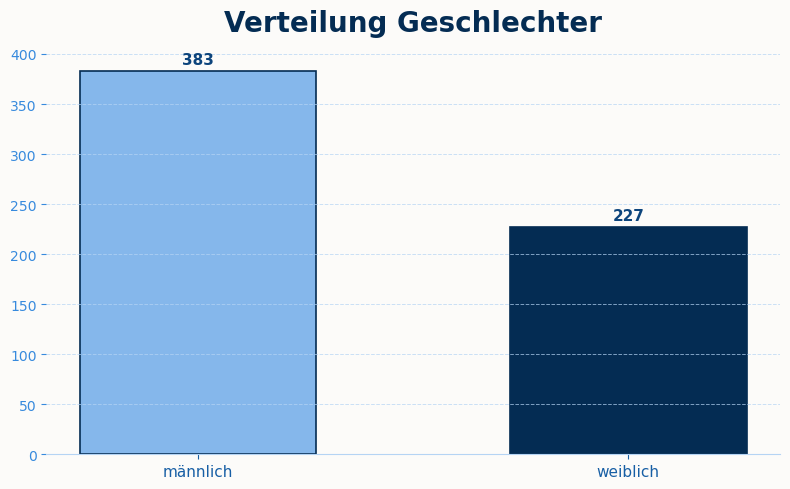

In [76]:
df = pd.read_csv("../data/wikipedia_text.csv", sep = ",")

counts = df.groupby("genderLabel").size()

fig, ax = plt.subplots(figsize=(8, 5))

blues = ["#85B7EB", "#042C53"]
colors = [blues[i % len(blues)] for i in range(len(counts))]

bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="#042C53",
              linewidth=1.2, width=0.55)

# Anzahl der Geschlechter oberhalb des Balkens
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + counts.values.max() * 0.01,
            f"{int(height):,}", ha="center", va="bottom",
            fontsize=11, fontweight="bold", color="#0C447C")

# Styling
ax.set_facecolor("#fcfbf9")
fig.patch.set_facecolor("#fcfbf9")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#B5D4F4")
ax.tick_params(axis="x", colors="#185FA5", labelsize=11)
ax.tick_params(axis="y", colors="#378ADD", labelsize=10)
ax.grid(axis="y", color="#B5D4F4", linestyle="--", linewidth=0.7, alpha=0.7)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_title("Verteilung Geschlechter", fontsize=20, fontweight="bold",
             color="#042C53", pad=15)
plt.tight_layout()
plt.savefig("../figures/verteilung_geschlechter.png", dpi=300)
plt.show()

## Stopwörter, Tokenisierung und Corpora
Die Stoppwörter werden nach der Standardliste von NLTK für Deutsch und Englisch erweitert um häufige, aber wenig informative Wörter aus Wikipedia-Texten (z.B. "abgerufen", "online", "doi").
 Die Tokenisierung erfolgt durch eine einfache Regex, die nur alphabetische Zeichen und deutsche Umlaute berücksichtigt. Wörter, die mit einem Großbuchstaben beginnen (vermutlich Substantive) werden ignoriert, um den Fokus auf Verben, Adjektive und andere Wortarten zu legen, die möglicherweise geschlechtsspezifische Assoziationen aufweisen.
 Gesamtheit aller Verben, die in den Texten der männlichen bzw. weiblichen Artikel vorkommen. Diese werden durch die Funktion `collect_corpora` erstellt, die die Texte der Artikel nach Geschlecht filtert und dann tokenisiert. Das Ergebnis ist ein Dictionary mit zwei Listen von Tokens: eine für "männlich" und eine für "weiblich". Diese Corpora bilden die Grundlage für die anschließende Häufigkeitsanalyse und PMI-Berechnung.

In [77]:
STOPWORDS = set(stopwords.words("german")) | set(stopwords.words("english"))

corpora = {"männlich": [], "weiblich": []}

for _, row in df.iterrows():
    gender = row["genderLabel"].strip().lower()
    if gender in corpora:
        text = row["text"]
        # Überschriften entfernen
        text = re.sub(r"={1,6}[^=]+={1,6}", "", text)

        doc = nlp(text[:100_000])
        tokens = []
        for token in doc:
            if token.pos_ not in {"VERB"}:  # nur verben ansehen
                continue
            w = token.lemma_.lower()
            if w not in STOPWORDS and len(w) > 2 and w.isalpha():
                tokens.append(w)

        corpora[gender].extend(tokens)

## Häufigkeitsanalyse und Rang-Korrelation
Die Funktion `word_frequencies` berechnet die relative Häufigkeit jedes Tokens in einem gegebenen Corpus, indem sie die Anzahl der Vorkommen eines Tokens durch die Gesamtzahl der Tokens teilt. Das Ergebnis ist ein Dictionary, das jedem Token seine relative Häufigkeit zuordnet.
Die Funktion `rank_correlation` berechnet die Spearman-Rangkorrelation zwischen den Häufigkeiten der gemeinsamen Tokens in den männlichen und weiblichen Corpora. Sie identifiziert die gemeinsamen Tokens, extrahiert ihre Häufigkeiten aus beiden Corpora und berechnet dann die Spearman-Korrelation, um zu bewerten, wie ähnlich die Rangordnungen der Token-Häufigkeiten zwischen den beiden Gruppen sind. Das Ergebnis umfasst den Korrelationskoeffizienten (ρ), den p-Wert und die Anzahl der gemeinsamen Tokens, die in die Berechnung einbezogen wurden.

In [78]:
# Worthäufigkeiten berechnen
counts_m = Counter(corpora["männlich"])
total_m = sum(counts_m.values())
freq_m = {w: c / total_m for w, c in counts_m.items()}

counts_f = Counter(corpora["weiblich"])
total_f = sum(counts_f.values())
freq_f = {w: c / total_f for w, c in counts_f.items()}

# Rang-Korrelation
common = set(freq_m) & set(freq_f)
words = list(common)
fm = [freq_m[w] for w in words]
ff = [freq_f[w] for w in words]
rho, pval = spearmanr(fm, ff)

print(f"Rang-Korrelation (gemeinsames Vokabular, n={len(common):,}):")
print(f"  ρ = {rho:.3f}  p = {pval:.2e}")

Rang-Korrelation (gemeinsames Vokabular, n=520):
  ρ = 0.705  p = 2.27e-79


### Interpretation Rang Korrelation
Ein hoher Spearman-Korrelationskoeffizient (ρ) nahe 1 würde darauf hindeuten, dass die Rangordnungen der Token-Häufigkeiten in den männlichen und weiblichen Corpora sehr ähnlich sind, was auf eine geringe sprachliche Verzerrung hinweisen könnte. Ein niedrigerer ρ-Wert würde hingegen auf größere Unterschiede in der Wortwahl zwischen den beiden Gruppen hindeuten, was auf ein sehr unterschiedliches Vokabular hindeuten.

## PMI (Pointwise Mutual Information): Wortassoziationen pro Gruppe

In [79]:
# PMI berechnen
all_tokens = corpora["männlich"] + corpora["weiblich"]
total = len(all_tokens)
n_male = len(corpora["männlich"])
n_female = len(corpora["weiblich"])

p_gender = {"männlich": n_male / total, "weiblich": n_female / total}

all_counts = Counter(all_tokens)
gender_counts = {g: Counter(corpora[g]) for g in ("männlich", "weiblich")}

pmi = defaultdict(dict)
for word, global_count in all_counts.items():
    if global_count < 60:
        continue
    p_word = global_count / total
    for gender in ("männlich", "weiblich"):
        gc = gender_counts[gender].get(word, 0)
        p_word_gender = gc / total
        if p_word_gender == 0:
            pmi[gender][word] = -np.inf
        else:
            pmi[gender][word] = math.log2(p_word_gender / (p_word * p_gender[gender]))

top_n = 30
top_male   = sorted(pmi["männlich"], key=lambda w: pmi["männlich"][w], reverse=True)[:top_n]
top_female = sorted(pmi["weiblich"], key=lambda w: pmi["weiblich"][w], reverse=True)[:top_n]

pmi_männlich = {w: pmi["männlich"][w] for w in top_male}
pmi_weiblich = {w: pmi["weiblich"][w] for w in top_female}

print("Top 10 männlich assoziierte Wörter (PMI):")
for w, s in list(pmi_männlich.items())[:10]:
    print(f"  {w:<25} {s:+.3f}")

print("\nTop 10 weiblich assoziierte Wörter (PMI):")
for w, s in list(pmi_weiblich.items())[:10]:
    print(f"  {w:<25} {s:+.3f}")

Top 10 männlich assoziierte Wörter (PMI):
  habilitieren              +0.496
  befassen                  +0.390
  berufen                   +0.389
  beteiligen                +0.304
  treten                    +0.280
  abgerufen                 +0.259
  ernennen                  +0.233
  übernehmen                +0.205
  gründen                   +0.192
  wählen                    +0.171

Top 10 weiblich assoziierte Wörter (PMI):
  gebären                   +0.368
  beginnen                  +0.365
  beschäftigen              +0.346
  leiten                    +0.292
  führen                    +0.282
  halten                    +0.256
  erwerben                  +0.252
  lehren                    +0.192
  forschen                  +0.162
  untersuchen               +0.123


# Visualisierungen

In [88]:
#| echo: false
def plot_pmi(pmi_data: dict, top_n: int = 20):
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.patch.set_facecolor("#fcfbf9")

    colors = {"männlich": "#85B7EB", "weiblich": "#042C53"}

    for ax, gender in zip(axes, ("männlich", "weiblich")):
        words = list(pmi_data[gender].keys())[:top_n]
        scores = [pmi_data[gender][w] for w in words]
        y_pos = np.arange(len(words))

        ax.barh(y_pos, scores, color=colors[gender], alpha=0.85, height=0.6)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(words, fontsize=10, color="#0C447C")
        ax.invert_yaxis()

        ax.set_facecolor("#fcfbf9")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["bottom", "left"]].set_color("#B5D4F4")
        ax.tick_params(axis="x", colors="#378ADD", labelsize=9)
        ax.tick_params(axis="y", colors="#0C447C", labelsize=12)
        ax.grid(axis="x", color="#B5D4F4", linestyle="--", linewidth=0.6, alpha=0.7)
        ax.set_xlabel("PMI (Bits)")
        ax.set_title(f"Top-Wörter assoziiert mit {'männlichen' if gender == 'männlich' else 'weiblichen'} Wissenschaftler:innen")
        ax.axvline(0, color="#185FA5", linewidth=0.9, linestyle="-")
    x_min = min(ax.get_xlim()[0] for ax in axes)
    x_max = max(ax.get_xlim()[1] for ax in axes)
    for ax in axes:
        ax.set_xlim(x_min, x_max)

    plt.suptitle("Wortassoziationen nach Geschlecht (PMI)",
                 fontsize=20, fontweight="bold", color="#042C53", y=1.01)
    plt.tight_layout()
    plt.show()

def plot_rank_scatter(freq_m: dict, freq_f: dict):
    common = set(freq_m) & set(freq_f)
    words = list(common)
    fm = np.array([freq_m[w] for w in words])
    ff = np.array([freq_f[w] for w in words])

    fig, ax = plt.subplots(figsize=(7, 7))
    fig.patch.set_facecolor("#fcfbf9")
    ax.set_facecolor("#fcfbf9")

    ax.scatter(np.log10(fm), np.log10(ff), alpha=0.25, s=6, color="#85B7EB")

    # Interessanteste Wörter annotieren
    interesting = sorted(common, key=lambda w: abs(freq_m[w] - freq_f[w]),
                         reverse=True)[:12]
    for w in interesting:
        ax.annotate(w, (np.log10(freq_m[w]), np.log10(freq_f[w])),
                    fontsize=10, color="#042C53", alpha=0.9,
                    xytext=(4, 4), textcoords="offset points")

    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, color="#378ADD", linewidth=0.9,
            linestyle="--", label="y = x")

    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["bottom", "left"]].set_color("#B5D4F4")
    ax.tick_params(axis="both", colors="#378ADD", labelsize=9)
    ax.grid(color="#B5D4F4", linestyle="--", linewidth=0.6, alpha=0.7)

    ax.set_xlabel("log₁₀(Häufigkeit) — männliche Wissenschaftler",
                  fontsize=11, color="#185FA5", labelpad=8)
    ax.set_ylabel("log₁₀(Häufigkeit) — weibliche Wissenschaftler",
                  fontsize=11, color="#185FA5", labelpad=8)
    ax.set_title("Worthäufigkeits-Scatter (gemeinsamer Wortschatz)",
                 fontsize=13, fontweight="bold", color="#042C53", pad=12)
    rho, p = spearmanr(fm, ff)
    ax.text(0.05, 0.95, f"Spearman ρ = {rho:.2f}",
            transform=ax.transAxes, color="#042C53", fontsize=10)
    legend = ax.legend(fontsize=10)
    legend.get_frame().set_facecolor("#fcfbf9")
    legend.get_frame().set_edgecolor("#B5D4F4")
    for text in legend.get_texts():
        text.set_color("#185FA5")

    plt.tight_layout()
    plt.show()

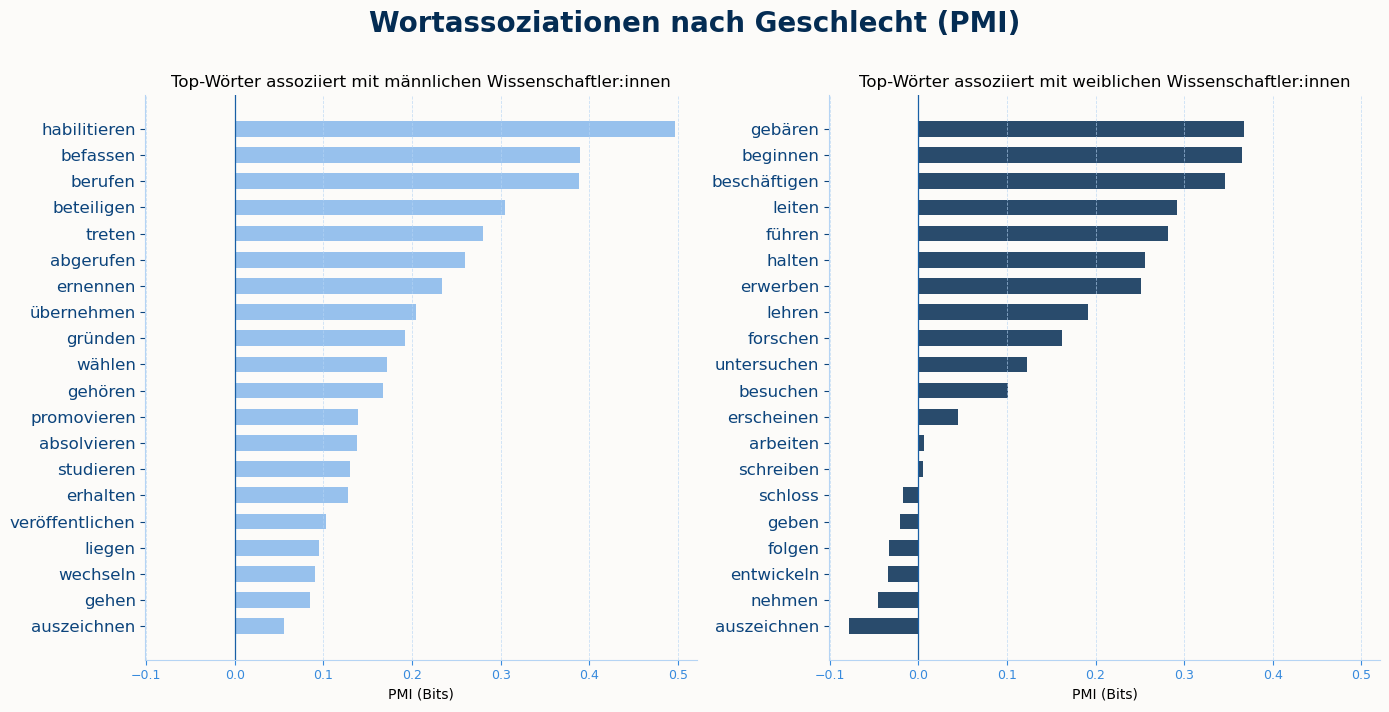

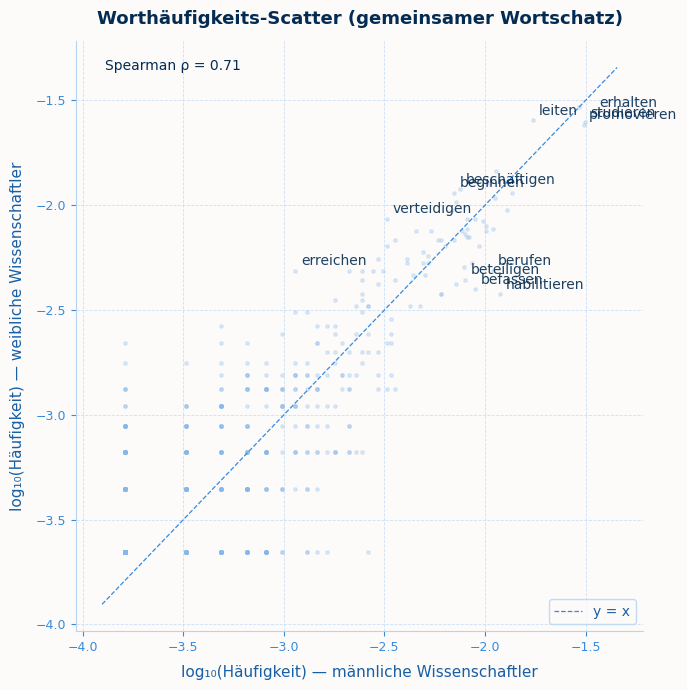

In [89]:
plot_pmi({"männlich": pmi_männlich, "weiblich": pmi_weiblich}, top_n=20)
plot_rank_scatter(freq_m, freq_f)

## Lexikon-basierter Ansatz

In [90]:
LEXIKA = {
    "Familie": {
        "kind", "kinder", "mutter", "vater", "familie", "familien",
        "heirat", "heiratete", "hochzeit", "ehe", "ehemann", "ehefrau",
        "tochter", "sohn", "geschwister", "eltern", "großeltern",
        "geburt", "geboren", "schwanger", "haushalt"
    },
    "Karriere": {
        "arbeit", "beruf", "karriere", "stelle", "position", "amt",
        "professur", "promotion", "habilitation", "gehalt", "preis",
        "auszeichnung", "award", "stipendium", "forschung", "labor",
        "publikation", "veröffentlichung", "patent", "erfindung"
    }
}

In [91]:
#| echo: false

def lexikon_analyse(corpora: dict, lexika: dict):
    ergebnisse = {}
    for kategorie, woerter in LEXIKA.items():
        ergebnisse[kategorie] = {}
        for gender, tokens in corpora.items():
            total = len(tokens)
            treffer = sum(1 for t in tokens if t in woerter)
            ergebnisse[kategorie][gender] = treffer / total * 1000  # pro 1000 Wörter
    return ergebnisse

def plot_lexikon(ergebnisse: dict):
    kategorien = list(ergebnisse.keys())
    x = np.arange(len(kategorien))
    breite = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - breite/2, [ergebnisse[k]["männlich"] for k in kategorien],
           breite, label="Männlich", color=COLORS["male"])
    ax.bar(x + breite/2, [ergebnisse[k]["weiblich"] for k in kategorien],
           breite, label="Weiblich", color=COLORS["female"])

    ax.set_xticks(x)
    ax.set_xticklabels(kategorien)
    ax.set_ylabel("Häufigkeit pro 1000 Wörter")
    ax.set_title("Lexikon-Analyse nach Geschlecht")
    ax.legend()
    plt.tight_layout()
    plt.show()


Lexikon-Analyse (pro 1000 Wörter):

  Familie:
    männlich: 0.00
    weiblich: 0.00

  Karriere:
    männlich: 0.00
    weiblich: 0.22


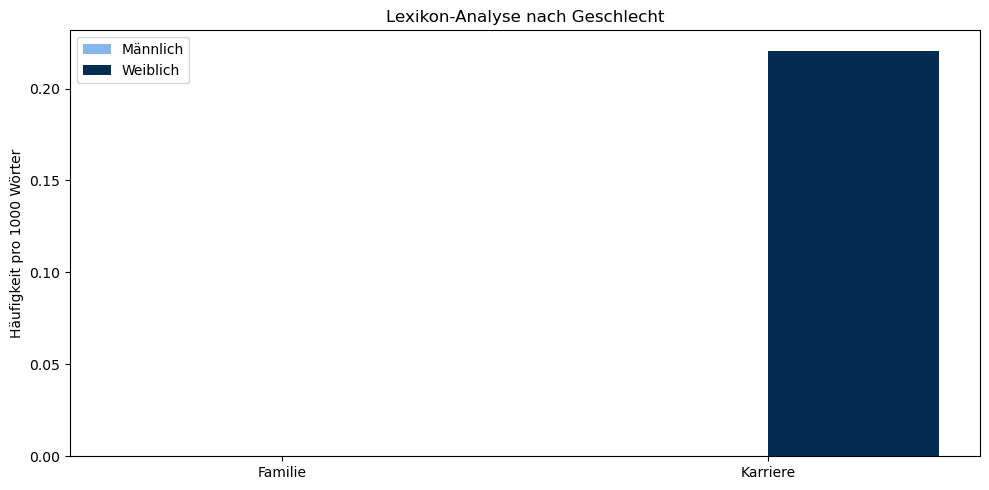

In [92]:
def main():

    ergebnisse = lexikon_analyse(corpora, LEXIKA)
    print("\nLexikon-Analyse (pro 1000 Wörter):")
    for kategorie, werte in ergebnisse.items():
        print(f"\n  {kategorie}:")
        for gender, wert in werte.items():
            print(f"    {gender}: {wert:.2f}")
    plot_lexikon(ergebnisse)

if __name__ == "__main__":
    main()